<div style="background: linear-gradient(135deg, #0F3D6E 0%, #2176AE 100%); padding: 40px 36px 32px 36px; border-radius: 10px; margin-bottom: 8px;">
  <p style="color: #C8DEF5; font-size: 13px; margin: 0 0 6px 0; letter-spacing: 2px;">CURSO 8 · MÓDULO 1 · CLASE 1</p>
  <h1 style="color: white; font-size: 36px; margin: 0 0 10px 0; font-weight: 700;">Álgebra Lineal para Modelos Estadísticos</h1>
  <p style="color: #C8DEF5; font-size: 16px; margin: 0 0 24px 0; font-style: italic;">Los fundamentos matriciales detrás de todo modelo estadístico</p>
  <hr style="border-color: #5BA4CF; margin: 0 0 20px 0;">
  <p style="color: #EAF2FB; font-size: 13px; margin: 0;">📌 <strong>Docente:</strong> Josef Rodriguez &nbsp;·&nbsp; <strong>Nivel:</strong> Avanzado &nbsp;·&nbsp; <strong>Duración:</strong> 2 horas &nbsp;·&nbsp; <strong>Herramienta:</strong> Python + NumPy</p>
</div>

## ¿Qué vas a aprender en este notebook?

Al ejecutar este notebook de inicio a fin vas a poder:

| # | Objetivo |
|---|----------|
| 1 | Operar matrices con fluidez en NumPy |
| 2 | Entender de dónde viene la fórmula de β̂ |
| 3 | Saber cuándo β̂ existe y es único (rango, multicolinealidad) |
| 4 | Calcular una regresión lineal **sin sklearn** — solo con la ecuación normal |
| 5 | Conectar todo esto con un caso de industria real |

> **Filosofía del notebook:** cada celda responde una pregunta. Si en algún momento te preguntás *¿por qué estamos haciendo esto?*, la celda de markdown anterior debería responderlo.

---
## 1. Importación de librerías

Solo lo necesario. En esta clase el protagonista es **NumPy** — el corazón del álgebra lineal en Python.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Configuración visual
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 42
np.random.seed(SEED)

print('✅ Librerías cargadas correctamente')
print(f'   NumPy  {np.__version__}')
print(f'   Pandas {pd.__version__}')

✅ Librerías cargadas correctamente
   NumPy  2.4.4
   Pandas 3.0.1


---
## 2. El lenguaje de los datos: escalares, vectores y matrices

Antes de tocar datos reales, necesitamos dominar los objetos básicos. Todo modelo estadístico que veremos en el curso vive en este lenguaje.

### 2.1 Escalar — un solo número

Un **escalar** es el objeto más simple: un único valor real. En regresión, los coeficientes β₀, β₁, … y el R² son escalares.

In [4]:
# Un escalar — simplemente un número
alpha = 3.14
R2    = 0.87
sigma = 1.5

print(f'α = {alpha}  |  R² = {R2}  |  σ = {sigma}')
print(f'Tipo de α: {type(alpha).__name__}')

α = 3.14  |  R² = 0.87  |  σ = 1.5
Tipo de α: float


### 2.2 Vector — una observación o un conjunto de parámetros

Un **vector** es un arreglo ordenado de escalares. En regresión:
- **y** = vector de respuestas (n × 1)
- **β** = vector de coeficientes (p × 1)
- Cada fila de X = un vector que representa un cliente/observación

> **Convención:** en álgebra lineal, los vectores son columna por defecto: **x** = (x₁, x₂, …, xₙ)ᵀ

In [5]:
# Vector de coeficientes (como los que estimaremos)
beta_true = np.array([5.0, 2.5, -1.8])   # β₀, β₁, β₂

# Vector de respuestas (5 observaciones)
y_ejemplo = np.array([12.3, 8.7, 15.1, 9.4, 11.8])

print('β verdadero:', beta_true, f'  shape={beta_true.shape}  → vector de {len(beta_true)} parámetros')
print('y ejemplo:  ', y_ejemplo, f'  shape={y_ejemplo.shape}  → {len(y_ejemplo)} observaciones')

# Norma de un vector: mide su 'tamaño'
norma = np.linalg.norm(beta_true)
print(f'\n‖β‖ = √(βᵀβ) = {norma:.4f}')

β verdadero: [ 5.   2.5 -1.8]   shape=(3,)  → vector de 3 parámetros
y ejemplo:   [12.3  8.7 15.1  9.4 11.8]   shape=(5,)  → 5 observaciones

‖β‖ = √(βᵀβ) = 5.8728


### 2.3 Matriz — el dataset completo

Una **matriz** organiza múltiples vectores. En regresión, la matriz de diseño **X** (n × p) tiene:
- **n filas** = observaciones (clientes, transacciones, …)
- **p columnas** = variables predictoras (+ columna de unos para el intercepto)

In [6]:
# Matriz de diseño simple: 5 clientes, 3 columnas (intercepto + 2 features)
# Columna 1: unos (para el intercepto β₀)
# Columna 2: ingresos normalizados
# Columna 3: antigüedad en años

X_ejemplo = np.array([
    [1,  2.1,  3],
    [1,  3.5,  7],
    [1,  1.8,  1],
    [1,  4.2, 10],
    [1,  2.9,  5],
], dtype=float)

n, p = X_ejemplo.shape
print(f'Matriz de diseño X: {n} observaciones × {p} columnas')
print(f'Columnas: [intercepto | ingresos | antigüedad]\n')
print(pd.DataFrame(X_ejemplo, columns=['intercepto', 'ingresos', 'antiguedad']))

Matriz de diseño X: 5 observaciones × 3 columnas
Columnas: [intercepto | ingresos | antigüedad]

   intercepto  ingresos  antiguedad
0         1.0       2.1         3.0
1         1.0       3.5         7.0
2         1.0       1.8         1.0
3         1.0       4.2        10.0
4         1.0       2.9         5.0


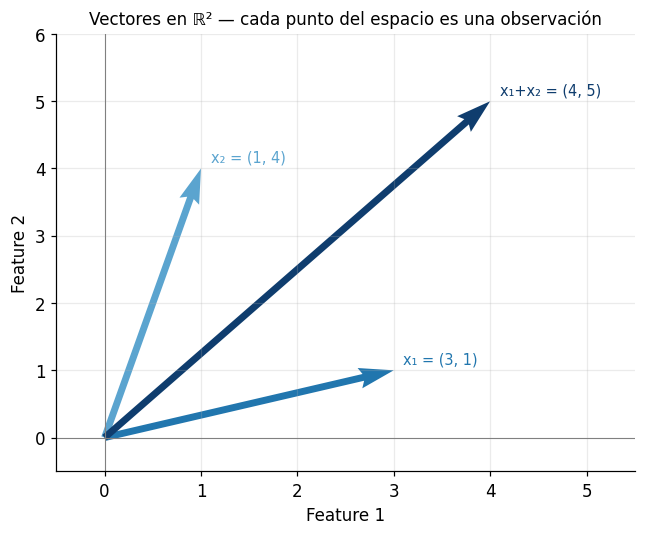

Intuición: cada fila de X es un punto (observación) en el espacio de features.


In [7]:
# Visualizar vectores en R² para tener intuición geométrica
fig, ax = plt.subplots(figsize=(6, 5))

vectores = {
    'x₁ = (3, 1)': (3, 1, '#2176AE'),
    'x₂ = (1, 4)': (1, 4, '#5BA4CF'),
    'x₁+x₂ = (4, 5)': (4, 5, '#0F3D6E'),
}

for label, (vx, vy, color) in vectores.items():
    ax.quiver(0, 0, vx, vy, angles='xy', scale_units='xy', scale=1,
              color=color, width=0.012, label=label)
    ax.text(vx + 0.1, vy + 0.1, label, fontsize=9.5, color=color)

ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 6)
ax.axhline(0, color='gray', lw=0.7)
ax.axvline(0, color='gray', lw=0.7)
ax.grid(True, alpha=0.25)
ax.set_title('Vectores en ℝ² — cada punto del espacio es una observación', fontsize=11)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print('Intuición: cada fila de X es un punto (observación) en el espacio de features.')

---
## 3. Operaciones con matrices que usarás en cada modelo

No son ejercicios abstractos — cada una aparece en la derivación de β̂.

### 3.1 Suma y producto

- **Suma A + B**: mismo orden, elemento a elemento
- **Producto AB**: columnas de A = filas de B → resultado m×n
- ⚠️ **AB ≠ BA** — el producto matricial NO es conmutativo

In [8]:
A = np.array([[1, 2], [3, 4]], dtype=float)
B = np.array([[5, 6], [7, 8]], dtype=float)

print('A:\n', A)
print('B:\n', B)
print('\nA + B:\n', A + B)       # suma elemento a elemento
print('\nAB (A @ B):\n', A @ B)  # producto matricial

# El producto NO es conmutativo — error frecuente en código
print(f'\nAB == BA? → {np.allclose(A @ B, B @ A)}')  # False
print('⚠  AB y BA tienen el mismo shape pero son matrices distintas.')

A:
 [[1. 2.]
 [3. 4.]]
B:
 [[5. 6.]
 [7. 8.]]

A + B:
 [[ 6.  8.]
 [10. 12.]]

AB (A @ B):
 [[19. 22.]
 [43. 50.]]

AB == BA? → False
⚠  AB y BA tienen el mismo shape pero son matrices distintas.


### 3.2 Transpuesta

Voltea filas y columnas: si A es m×n, entonces Aᵀ es n×m.

**Propiedad crítica en OLS:** (AB)ᵀ = BᵀAᵀ — esto aparece al derivar la función de costo.

In [9]:
A = np.array([[1, 2, 3],
              [4, 5, 6]], dtype=float)   # 2×3

print('A (2×3):\n', A)
print('\nAᵀ (3×2):\n', A.T)

# Verificar (AB)ᵀ = BᵀAᵀ
B = np.random.randn(3, 4)
lhs = (A @ B).T       # (AB)ᵀ
rhs = B.T @ A.T       #  BᵀAᵀ

print(f'\n(AB)ᵀ == BᵀAᵀ → {np.allclose(lhs, rhs)}  ✓')

A (2×3):
 [[1. 2. 3.]
 [4. 5. 6.]]

Aᵀ (3×2):
 [[1. 4.]
 [2. 5.]
 [3. 6.]]

(AB)ᵀ == BᵀAᵀ → True  ✓


### 3.3 Traza

Suma de la diagonal principal. Solo para matrices cuadradas.

**¿Por qué importa?** → `tr(H) = p` siempre, donde H es la hat matrix. Eso nos da los grados de libertad del modelo.

In [10]:
A = np.array([[3, 1, 2],
              [0, 5, 7],
              [4, 6, 8]], dtype=float)

print('Diagonal de A:', np.diag(A))       # [3, 5, 8]
print('tr(A)        :', np.trace(A))      # 3 + 5 + 8 = 16

# Propiedad cíclica: tr(AB) = tr(BA) — útil en derivaciones
B = np.random.randn(3, 3)
print(f'\ntr(AB) = {np.trace(A @ B):.6f}')
print(f'tr(BA) = {np.trace(B @ A):.6f}')
print(f'¿Iguales? → {np.isclose(np.trace(A @ B), np.trace(B @ A))}  ✓')

Diagonal de A: [3. 5. 8.]
tr(A)        : 16.0

tr(AB) = -9.891728
tr(BA) = -9.891728
¿Iguales? → True  ✓


---
## 4. El corazón de OLS: formas cuadráticas

Acá está la conexión entre álgebra lineal y optimización. OLS minimiza la suma de cuadrados de los residuos — y eso es una **forma cuadrática** en β.

### 4.1 ¿Qué es una forma cuadrática?

Q(x) = xᵀAx

Si **A** es simétrica definida positiva → Q(x) > 0 para todo x ≠ 0 → el mínimo existe y es único.

**¿Cómo sabemos si A es definida positiva?** → Todos sus eigenvalues son > 0.

In [11]:
# Matriz simétrica definida positiva
A = np.array([[4, 2],
              [2, 3]], dtype=float)

x = np.array([1.0, 2.0])

# Forma cuadrática
Q = x @ A @ x
print(f'Q(x) = xᵀAx = {Q}')

# Verificar definida positiva
eigvals = np.linalg.eigvalsh(A)
print(f'Eigenvalues de A: {eigvals}')
print(f'¿Todos > 0? → {np.all(eigvals > 0)}  → A es definida positiva ✓')

Q(x) = xᵀAx = 24.0
Eigenvalues de A: [1.4384 5.5616]
¿Todos > 0? → True  → A es definida positiva ✓


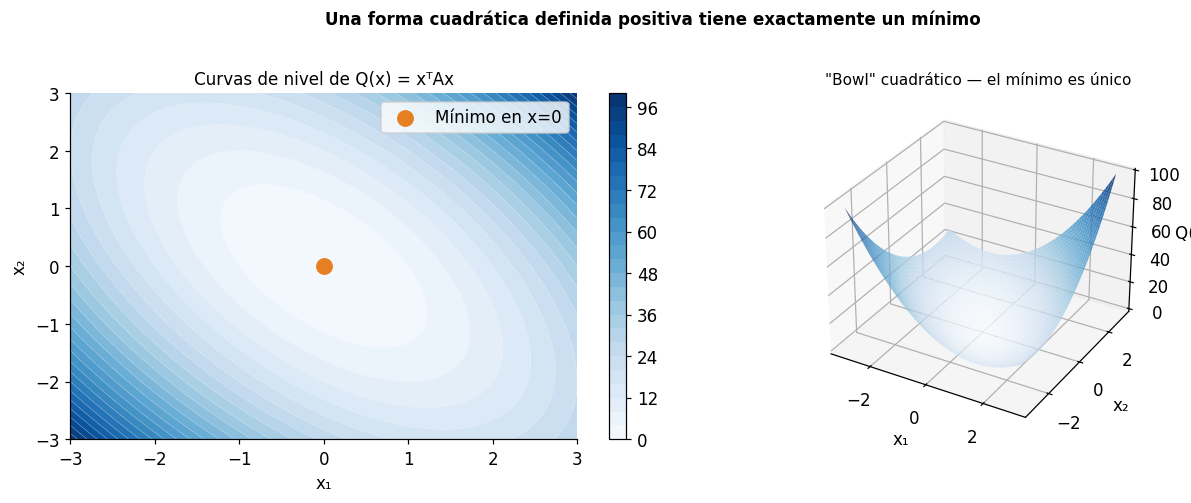

Intuición OLS: SSE(β) tiene exactamente esta forma en β → el mínimo es β̂.


In [12]:
# Visualizar Q(x) = xᵀAx — la forma del 'bowl' que OLS minimiza
grid = np.linspace(-3, 3, 200)
X1, X2 = np.meshgrid(grid, grid)
Q_vals = np.zeros_like(X1)

for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        v = np.array([X1[i,j], X2[i,j]])
        Q_vals[i,j] = v @ A @ v

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Curvas de nivel
cp = axes[0].contourf(X1, X2, Q_vals, levels=25, cmap='Blues')
axes[0].contour(X1, X2, Q_vals, levels=25, colors='white', linewidths=0.4, alpha=0.5)
axes[0].scatter([0], [0], color='#E67E22', s=100, zorder=5, label='Mínimo en x=0')
plt.colorbar(cp, ax=axes[0])
axes[0].set_title('Curvas de nivel de Q(x) = xᵀAx', fontsize=11)
axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')
axes[0].legend()

# Superficie
ax3d = fig.add_subplot(122, projection='3d', label='q3d')
axes[1].remove()
ax3d.plot_surface(X1, X2, Q_vals, cmap='Blues', alpha=0.85, linewidth=0)
ax3d.set_xlabel('x₁'); ax3d.set_ylabel('x₂'); ax3d.set_zlabel('Q(x)')
ax3d.set_title('"Bowl" cuadrático — el mínimo es único', fontsize=10)

plt.suptitle('Una forma cuadrática definida positiva tiene exactamente un mínimo', 
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Intuición OLS: SSE(β) tiene exactamente esta forma en β → el mínimo es β̂.')

### 4.2 Derivación de la ecuación normal

OLS minimiza SSE = (y − Xβ)ᵀ(y − Xβ). Expandiendo:

$$SSE(\beta) = \mathbf{y}^\top\mathbf{y} - 2\boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{y} + \boldsymbol{\beta}^\top(\mathbf{X}^\top\mathbf{X})\boldsymbol{\beta}$$

Derivando e igualando a cero:

$$\frac{\partial SSE}{\partial \boldsymbol{\beta}} = -2\mathbf{X}^\top\mathbf{y} + 2(\mathbf{X}^\top\mathbf{X})\boldsymbol{\beta} = \mathbf{0}$$

$$\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}}$$

> Esta fórmula existe y es única **si y solo si** XᵀX es invertible → rank(X) = p.

---
## 5. Carga y exploración del dataset

Usamos **California Housing** — precios de viviendas en California. Dataset clásico, ideal para regresión lineal.

**Objetivo de negocio:** estimar el precio mediano de una vivienda a partir de características del bloque censal.

In [13]:
# Dataset sintético de viviendas — no requiere descarga
# Simula las características clave de California Housing
# Variables: ingreso_med, edad_casa, avg_rooms, poblacion → precio

np.random.seed(SEED)
N = 2000

ingreso_med  = np.random.gamma(3, 2, N)          # ingreso mediano (normalizado)
edad_casa    = np.random.uniform(1, 52, N)        # años de antigüedad
avg_rooms    = np.random.gamma(6, 1, N)           # promedio de habitaciones
poblacion    = np.random.gamma(3, 500, N)         # población del bloque

# Target: precio mediano (en cientos de miles USD)
precio = (ingreso_med * 0.45
          + edad_casa  * 0.005
          - avg_rooms  * 0.03
          - poblacion  * 0.00004
          + np.random.normal(0, 0.25, N))

precio = np.clip(precio, 0.5, 5.0)   # rango realista

df = pd.DataFrame({
    'MedInc':         ingreso_med,
    'HouseAge':       edad_casa,
    'AveRooms':       avg_rooms,
    'Population':     poblacion,
    'precio_mediano': precio,
})

print(f'Dataset: {df.shape[0]:,} bloques censales × {df.shape[1]} variables')
print(f'Target:  precio mediano de vivienda (en cientos de miles USD)\n')
print(df.dtypes)

Dataset: 2,000 bloques censales × 5 variables
Target:  precio mediano de vivienda (en cientos de miles USD)

MedInc            float64
HouseAge          float64
AveRooms          float64
Population        float64
precio_mediano    float64
dtype: object


In [14]:
# Vista rápida de los primeros registros
df.head()

,MedInc,HouseAge,AveRooms,Population,precio_mediano
0,7.125637,21.415955,3.839016,2294.157061,2.912835
1,4.894389,42.405172,5.640837,530.732040,2.216542
2,4.604561,1.706969,5.239518,1281.488733,1.709167
3,4.604610,34.118320,3.379611,995.147935,1.920331
4,12.332280,35.112703,5.450572,1376.624877,5.000000


In [15]:
# Estadísticas básicas — detectar escalas muy distintas entre variables
df.describe().round(2)

,MedInc,HouseAge,AveRooms,Population,precio_mediano
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,6.09,26.49,6.01,1504.80,2.55
std,3.46,14.82,2.47,826.43,1.34
min,0.21,1.01,0.69,78.43,0.50
25%,3.55,13.61,4.25,903.61,1.47
50%,5.48,26.13,5.61,1340.96,2.37
75%,7.82,39.58,7.47,1952.52,3.46
max,31.18,51.97,18.90,5177.90,5.00


### 5.1 Dos visualizaciones clave

Antes de modelar, siempre entender la distribución del target y las correlaciones más fuertes.

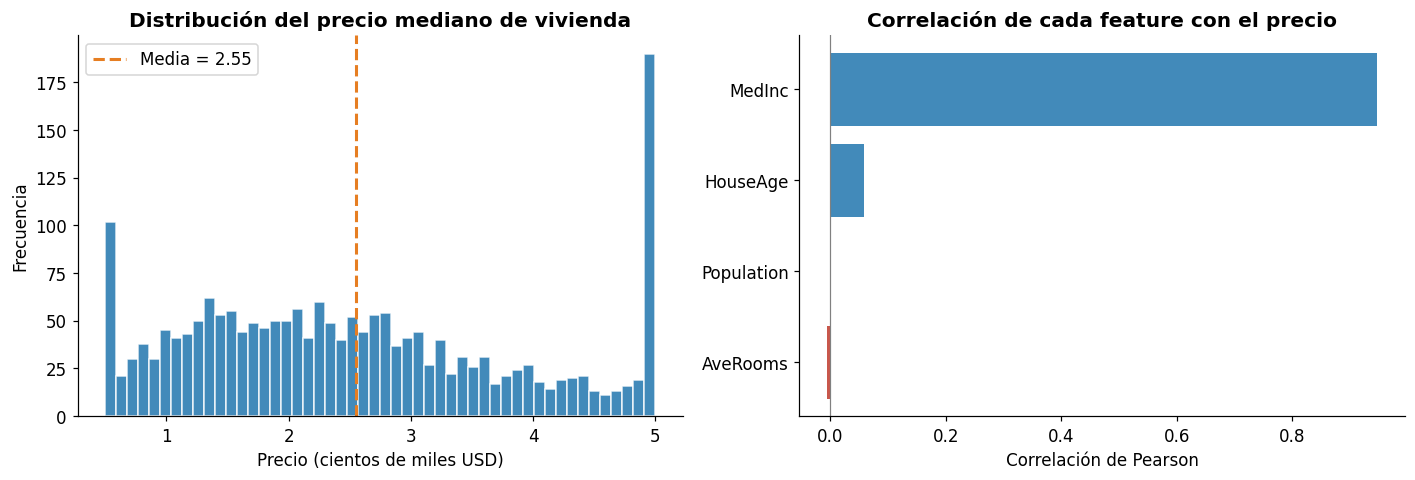

Observación: MedInc (ingreso mediano) es la variable más correlacionada con el precio.
AveRooms y otras tienen correlación débil o negativa.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Distribución del precio objetivo
axes[0].hist(df['precio_mediano'], bins=50, color='#2176AE', edgecolor='white', alpha=0.85)
axes[0].axvline(df['precio_mediano'].mean(), color='#E67E22', lw=2, linestyle='--',
                label=f'Media = {df["precio_mediano"].mean():.2f}')
axes[0].set_title('Distribución del precio mediano de vivienda', fontweight='bold')
axes[0].set_xlabel('Precio (cientos de miles USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# 2. Correlación con el target
corr = df.corr(numeric_only=True)['precio_mediano'].drop('precio_mediano').sort_values()
colors = ['#C0392B' if c < 0 else '#2176AE' for c in corr]
axes[1].barh(corr.index, corr.values, color=colors, alpha=0.85)
axes[1].axvline(0, color='gray', lw=0.8)
axes[1].set_title('Correlación de cada feature con el precio', fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.show()

print('Observación: MedInc (ingreso mediano) es la variable más correlacionada con el precio.')
print('AveRooms y otras tienen correlación débil o negativa.')

---
## 6. Preprocesamiento

Tres pasos: selección de features, estandarización y split train/test.

In [17]:
# Seleccionamos 4 features interpretables para mantener el modelo legible
features = ['MedInc', 'HouseAge', 'AveRooms', 'Population']
target   = 'precio_mediano'

X_raw = df[features].values
y     = df[target].values

print(f'X_raw shape: {X_raw.shape}   → {X_raw.shape[0]:,} obs × {X_raw.shape[1]} features')
print(f'y     shape: {y.shape}')

X_raw shape: (2000, 4)   → 2,000 obs × 4 features
y     shape: (2000,)


In [18]:
# Estandarizar: media=0, std=1 por columna
# Esto reduce el número de condición de XᵀX y mejora la estabilidad numérica

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Agregar la columna de unos para el intercepto β₀
n = X_scaled.shape[0]
X = np.column_stack([np.ones(n), X_scaled])   # n × (p+1)

print(f'X con intercepto: {X.shape}  → columnas: [β₀ | {" | ".join(features)}]')
print(f'\nPrimera fila de X (intercepto=1, resto estandarizado):')
print(X[0].round(4))

X con intercepto: (2000, 5)  → columnas: [β₀ | MedInc | HouseAge | AveRooms | Population]

Primera fila de X (intercepto=1, resto estandarizado):
[ 1.      0.2984 -0.3423 -0.8799  0.9554]


In [19]:
# Split train / test: 80% entrenamiento, 20% evaluación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'Train: {X_train.shape[0]:,} observaciones')
print(f'Test:  {X_test.shape[0]:,} observaciones')

Train: 1,600 observaciones
Test:  400 observaciones


---
## 7. Diagnóstico matricial antes de modelar

**Antes de invertir XᵀX siempre verificar:**
1. Rango completo → la inversa existe
2. Número de condición → la inversión es estable

In [20]:
# Calcular XᵀX sobre el conjunto de entrenamiento
XtX = X_train.T @ X_train

n_train, p = X_train.shape

print(f'XᵀX shape: {XtX.shape}  (p × p, con p = {p} columnas)\n')

# Diagnóstico 1: rango
rango = np.linalg.matrix_rank(X_train)
print(f'rank(X)     = {rango}  (esperado: {p})  → ¿rango completo? {rango == p}')

# Diagnóstico 2: determinante
det = np.linalg.det(XtX)
print(f'det(XᵀX)    = {det:.2e}  → ¿≠ 0? {abs(det) > 1e-10}')

# Diagnóstico 3: número de condición
cond = np.linalg.cond(XtX)
estado = '✓ Estable' if cond < 1000 else ('⚠ Atención' if cond < 1e6 else '✗ Peligro')
print(f'cond(XᵀX)   = {cond:.1f}  → {estado}')

# Diagnóstico 4: eigenvalues (todos > 0 = definida positiva)
eigvals = np.linalg.eigvalsh(XtX)
print(f'\nEigenvalues de XᵀX (mín/máx): {eigvals.min():.2f} / {eigvals.max():.2f}')
print(f'¿Todos > 0 (def. positiva)?   {np.all(eigvals > 0)}')

XᵀX shape: (5, 5)  (p × p, con p = 5 columnas)

rank(X)     = 5  (esperado: 5)  → ¿rango completo? True
det(XᵀX)    = 1.05e+16  → ¿≠ 0? True
cond(XᵀX)   = 1.1  → ✓ Estable

Eigenvalues de XᵀX (mín/máx): 1494.91 / 1706.48
¿Todos > 0 (def. positiva)?   True


---
## 8. Implementación: β̂ desde cero

Ahora calculamos β̂ usando la ecuación normal. **Sin sklearn.** Solo NumPy y la fórmula que derivamos.

In [21]:
# ── Paso 1: XᵀX ──────────────────────────────────────────────────────────────
XtX = X_train.T @ X_train        # p × p

# ── Paso 2: (XᵀX)⁻¹ ─────────────────────────────────────────────────────────
XtX_inv = np.linalg.inv(XtX)    # p × p

# ── Paso 3: Xᵀy ──────────────────────────────────────────────────────────────
Xty = X_train.T @ y_train        # p × 1

# ── Paso 4: β̂ = (XᵀX)⁻¹ Xᵀy ─────────────────────────────────────────────────
beta_hat = XtX_inv @ Xty

print('Coeficientes estimados β̂:')
print(f'  β₀ (intercepto): {beta_hat[0]:.4f}')
for i, feat in enumerate(features):
    print(f'  β{i+1} ({feat:12s}): {beta_hat[i+1]:.4f}')

Coeficientes estimados β̂:
  β₀ (intercepto): 2.5547
  β1 (MedInc      ): 1.2842
  β2 (HouseAge    ): 0.0610
  β3 (AveRooms    ): -0.0722
  β4 (Population  ): -0.0320


In [22]:
# Verificar con numpy.linalg.lstsq — versión numéricamente robusta
# En producción siempre usar lstsq (más estable que inv cuando hay casi-singularidad)

beta_lstsq, _, _, _ = np.linalg.lstsq(X_train, y_train, rcond=None)

print('¿inv() y lstsq() dan el mismo resultado?')
print(f'  Max diferencia: {np.max(np.abs(beta_hat - beta_lstsq)):.2e}  → {np.allclose(beta_hat, beta_lstsq)}')
print('\nRegla práctica: usar lstsq() en producción — maneja casos casi-singulares con gracia.')

¿inv() y lstsq() dan el mismo resultado?
  Max diferencia: 5.33e-15  → True

Regla práctica: usar lstsq() en producción — maneja casos casi-singulares con gracia.


---
## 9. La hat matrix H — geometría de OLS

**H = X(XᵀX)⁻¹Xᵀ** proyecta y sobre el espacio columna de X.

Propiedades que siempre deben cumplirse:
- **Idempotente:** H² = H
- **Simétrica:** H = Hᵀ
- **tr(H) = p** (grados de libertad del modelo)

In [23]:
# Calcular H (usamos subconjunto de 500 obs para que sea manejable)
X_sub   = X_train[:500]
XtX_sub = X_sub.T @ X_sub
XtX_inv_sub = np.linalg.inv(XtX_sub)

H = X_sub @ XtX_inv_sub @ X_sub.T    # 500 × 500

print(f'H shape: {H.shape}  (n × n)\n')

# Tests de propiedades
print(f'H idempotente (H² = H):  {np.allclose(H @ H, H)}')
print(f'H simétrica (H = Hᵀ):   {np.allclose(H, H.T)}')
print(f'tr(H) = {np.trace(H):.4f}  (debe ser ≈ p = {X_sub.shape[1]})')
print(f'\nLos valores de la diagonal de H (leverage) están entre 0 y 1:')
print(f'  min(hᵢᵢ) = {np.diag(H).min():.4f}')
print(f'  max(hᵢᵢ) = {np.diag(H).max():.4f}')

H shape: (500, 500)  (n × n)

H idempotente (H² = H):  True
H simétrica (H = Hᵀ):   True
tr(H) = 5.0000  (debe ser ≈ p = 5)

Los valores de la diagonal de H (leverage) están entre 0 y 1:
  min(hᵢᵢ) = 0.0023
  max(hᵢᵢ) = 0.0759


---
## 10. Evaluación del modelo

Calculamos las métricas clave e interpretamos qué significan.

In [24]:
# Predicciones
y_pred_train = X_train @ beta_hat
y_pred_test  = X_test  @ beta_hat

# Residuos (conjunto de entrenamiento)
e_train = y_train - y_pred_train

# Métricas
n_train, p = X_train.shape

SSE   = e_train @ e_train
SST   = (y_train - y_train.mean()) @ (y_train - y_train.mean())
R2_train = 1 - SSE / SST
R2_test  = r2_score(y_test, y_pred_test)

sigma2_hat = SSE / (n_train - p)    # estimador insesgado de σ²
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Verificar condición de optimalidad: Xᵀe ≈ 0
xt_e = X_train.T @ e_train

print('─' * 45)
print('         MÉTRICAS DE EVALUACIÓN')
print('─' * 45)
print(f'  R² train:     {R2_train:.4f}  (% varianza explicada en train)')
print(f'  R² test:      {R2_test:.4f}  (% varianza explicada en test)')
print(f'  RMSE test:    {rmse_test:.4f}  (error en unidades del target)')
print(f'  σ̂² (insesg.): {sigma2_hat:.4f}  (varianza residual estimada)')
print('─' * 45)
print(f'\n  Xᵀe ≈ 0 (condición de óptimo): {np.allclose(xt_e, 0, atol=1e-6)}')
print(f'  Norma de Xᵀe: {np.linalg.norm(xt_e):.2e}  ← debe ser ≈ 0')

─────────────────────────────────────────────
         MÉTRICAS DE EVALUACIÓN
─────────────────────────────────────────────
  R² train:     0.9123  (% varianza explicada en train)
  R² test:      0.8573  (% varianza explicada en test)
  RMSE test:    0.4839  (error en unidades del target)
  σ̂² (insesg.): 0.1597  (varianza residual estimada)
─────────────────────────────────────────────

  Xᵀe ≈ 0 (condición de óptimo): True
  Norma de Xᵀe: 1.17e-12  ← debe ser ≈ 0


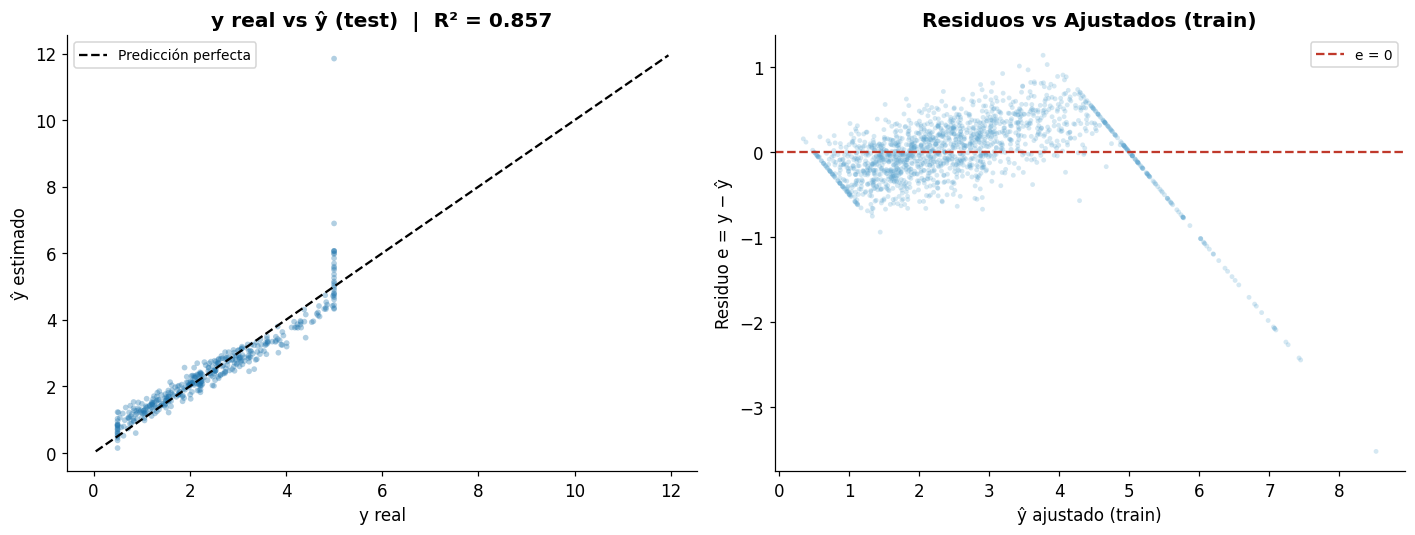

Qué buscar:
  ▸ Panel izq: puntos cerca de la diagonal → buen ajuste
  ▸ Panel der: residuos sin patrón → homocedasticidad (supuesto de OLS)


In [25]:
# Visualización de diagnóstico — dos gráficos clave
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. y real vs ŷ estimado (test set)
axes[0].scatter(y_test, y_pred_test, alpha=0.35, s=14,
                color='#2176AE', edgecolors='none')
lim = [min(y_test.min(), y_pred_test.min()) - 0.1,
       max(y_test.max(), y_pred_test.max()) + 0.1]
axes[0].plot(lim, lim, 'k--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('y real')
axes[0].set_ylabel('ŷ estimado')
axes[0].set_title(f'y real vs ŷ (test)  |  R² = {R2_test:.3f}', fontweight='bold')
axes[0].legend(fontsize=9)

# 2. Residuos vs ajustados (train set)
axes[1].scatter(y_pred_train, e_train, alpha=0.25, s=10,
                color='#5BA4CF', edgecolors='none')
axes[1].axhline(0, color='#C0392B', lw=1.5, linestyle='--', label='e = 0')
axes[1].set_xlabel('ŷ ajustado (train)')
axes[1].set_ylabel('Residuo e = y − ŷ')
axes[1].set_title('Residuos vs Ajustados (train)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Qué buscar:')
print('  ▸ Panel izq: puntos cerca de la diagonal → buen ajuste')
print('  ▸ Panel der: residuos sin patrón → homocedasticidad (supuesto de OLS)')

### Interpretación de los coeficientes

Como estandarizamos las variables, los coeficientes son comparables entre sí.

   Feature  Coeficiente                          Efecto
intercepto       2.5547                            Base
    MedInc       1.2842     +1.284 por 1 SD ↑ en MedInc
  HouseAge       0.0610   +0.061 por 1 SD ↑ en HouseAge
  AveRooms      -0.0722   -0.072 por 1 SD ↑ en AveRooms
Population      -0.0320 -0.032 por 1 SD ↑ en Population


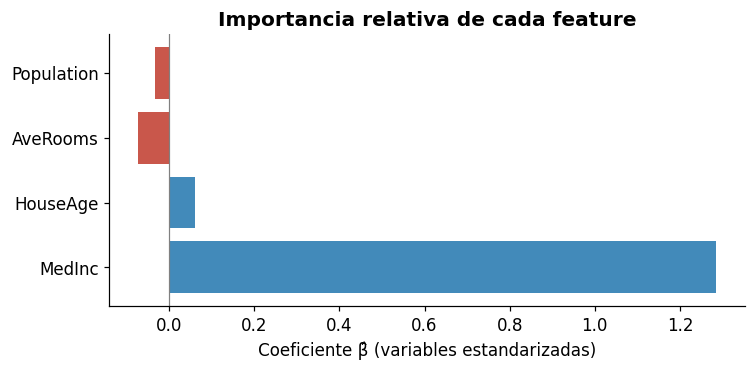

In [26]:
# Tabla de coeficientes interpretable
col_names = ['intercepto'] + features
coef_df = pd.DataFrame({
    'Feature':     col_names,
    'Coeficiente': beta_hat.round(4),
    'Efecto':      ['Base' if i==0 else
                    (f'+{beta_hat[i]:.3f} por 1 SD ↑ en {features[i-1]}'
                     if beta_hat[i] > 0 else
                     f'{beta_hat[i]:.3f} por 1 SD ↑ en {features[i-1]}')
                    for i in range(len(col_names))]
})

print(coef_df.to_string(index=False))

# Gráfico de importancia
fig, ax = plt.subplots(figsize=(7, 3.5))
betas_feat = beta_hat[1:]   # sin intercepto
colors = ['#2176AE' if b > 0 else '#C0392B' for b in betas_feat]
ax.barh(features, betas_feat, color=colors, alpha=0.85)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Coeficiente β̂ (variables estandarizadas)')
ax.set_title('Importancia relativa de cada feature', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Matrices especiales en acción

Verificamos todas las propiedades teóricas con los datos reales.

In [27]:
# ── XᵀX siempre simétrica ───────────────────────────────────────────────────
XtX_full = X_train.T @ X_train
print(f'XᵀX simétrica (XᵀX = (XᵀX)ᵀ):  {np.allclose(XtX_full, XtX_full.T)}')

# ── (XᵀX)⁻¹ también simétrica ───────────────────────────────────────────────
XtX_inv_full = np.linalg.inv(XtX_full)
print(f'(XᵀX)⁻¹ simétrica:               {np.allclose(XtX_inv_full, XtX_inv_full.T)}')

# ── I−H idempotente ───────────────────────────────────────────────────────────
M = np.eye(500) - H
print(f'(I−H) idempotente ((I−H)²=I−H):  {np.allclose(M @ M, M)}')

# ── Residuos = My para la sub-regresión en X_sub ──────────────────────────────
# Nota: β̂_sub se estima sobre los primeros 500 datos (X_sub)
beta_sub, _, _, _ = np.linalg.lstsq(X_sub, y_train[:500], rcond=None)
e_via_M   = M @ y_train[:500]                # proyección ortogonal
e_directo = y_train[:500] - X_sub @ beta_sub # residuos directos
print(f'e = My = y − Xβ̂:                  {np.allclose(e_via_M, e_directo, atol=1e-9)}')

XᵀX simétrica (XᵀX = (XᵀX)ᵀ):  True
(XᵀX)⁻¹ simétrica:               True
(I−H) idempotente ((I−H)²=I−H):  True
e = My = y − Xβ̂:                  True


---
## 12. Ejemplo aplicado: Credit Scoring en banca

Vamos a simular cómo se usa exactamente este pipeline en un modelo de scoring bancario real.

In [28]:
# Simular datos de clientes bancarios
# Objetivo: estimar el score crediticio a partir de variables financieras

np.random.seed(SEED)
n_clientes = 1000

# Features del cliente
ingresos    = np.random.normal(50_000, 20_000, n_clientes)       # USD/año
antiguedad  = np.random.randint(0, 30, n_clientes).astype(float) # años en trabajo
deuda_ratio = np.random.uniform(0.05, 0.85, n_clientes)          # deuda/ingreso
num_productos = np.random.randint(1, 6, n_clientes).astype(float)# productos con el banco

# Score verdadero (con ruido)
beta_real = np.array([500, 0.003, 4.0, -120.0, 15.0])            # [β₀, β_ing, β_ant, β_deu, β_prod]
ruido     = np.random.normal(0, 25, n_clientes)
score_real = (beta_real[0]
              + beta_real[1] * ingresos
              + beta_real[2] * antiguedad
              + beta_real[3] * deuda_ratio
              + beta_real[4] * num_productos
              + ruido)

# Clip entre 300 y 850 (rango real de FICO)
score_real = np.clip(score_real, 300, 850)

print(f'Dataset simulado: {n_clientes:,} clientes')
print(f'Score promedio: {score_real.mean():.1f}  (FICO real típico: 600–750)')
print(f'Rango: [{score_real.min():.0f}, {score_real.max():.0f}]')

Dataset simulado: 1,000 clientes
Score promedio: 696.8  (FICO real típico: 600–750)
Rango: [462, 850]


In [29]:
# Pipeline completo: desde raw hasta β̂

X_bank_raw = np.column_stack([ingresos, antiguedad, deuda_ratio, num_productos])
y_bank     = score_real

# Estandarizar
scaler_bank  = StandardScaler()
X_bank_sc    = scaler_bank.fit_transform(X_bank_raw)

# Agregar intercepto
X_bank = np.column_stack([np.ones(n_clientes), X_bank_sc])

# Split
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_bank, y_bank, test_size=0.2, random_state=SEED
)

# Diagnóstico matricial
XtX_b   = X_b_train.T @ X_b_train
print(f'rank(X) = {np.linalg.matrix_rank(X_b_train)}  (p = {X_b_train.shape[1]})  → rango completo')
print(f'cond(XᵀX) = {np.linalg.cond(XtX_b):.1f}  → estable ✓')

# Estimar β̂
beta_bank, _, _, _ = np.linalg.lstsq(X_b_train, y_b_train, rcond=None)

# Evaluar
y_b_pred = X_b_test @ beta_bank
R2_bank  = r2_score(y_b_test, y_b_pred)
rmse_bank = np.sqrt(mean_squared_error(y_b_test, y_b_pred))

print(f'\nResultados del modelo de scoring:')
print(f'  R²   = {R2_bank:.4f}   → explica el {R2_bank*100:.1f}% de la variación del score')
print(f'  RMSE = {rmse_bank:.2f} puntos FICO')

rank(X) = 5  (p = 5)  → rango completo
cond(XᵀX) = 1.2  → estable ✓

Resultados del modelo de scoring:
  R²   = 0.8979   → explica el 89.8% de la variación del score
  RMSE = 25.63 puntos FICO


In [30]:
# Tabla de coeficientes — interpretación de negocio
feat_names_bank = ['intercepto', 'ingresos', 'antiguedad', 'deuda_ratio', 'num_productos']

print('Coeficientes del modelo (variables estandarizadas):')
print('─' * 55)
for nombre, coef in zip(feat_names_bank, beta_bank):
    signo = '▲' if coef > 0 else '▼'
    print(f'  {nombre:16s}: {coef:+8.2f}  {signo}')
print('─' * 55)
print()
print('Interpretación de negocio:')
print('  ▲ ingresos    → más ingresos, mejor score  (esperado)')
print('  ▲ antiguedad  → más estabilidad laboral, mejor score')
print('  ▼ deuda_ratio → más endeudado, peor score  (esperado)')
print('  ▲ productos   → más fidelidad con el banco, mejor score')

Coeficientes del modelo (variables estandarizadas):
───────────────────────────────────────────────────────
  intercepto      :  +696.99  ▲
  ingresos        :   +56.32  ▲
  antiguedad      :   +32.68  ▲
  deuda_ratio     :   -27.85  ▼
  num_productos   :   +20.91  ▲
───────────────────────────────────────────────────────

Interpretación de negocio:
  ▲ ingresos    → más ingresos, mejor score  (esperado)
  ▲ antiguedad  → más estabilidad laboral, mejor score
  ▼ deuda_ratio → más endeudado, peor score  (esperado)
  ▲ productos   → más fidelidad con el banco, mejor score


In [31]:
# Simular decisión de crédito con el modelo
print('─' * 60)
print('  SIMULACIÓN: nuevos solicitantes de crédito')
print('─' * 60)

nuevos = np.array([
    [75_000, 8,  0.25, 3],   # cliente A: bueno
    [22_000, 1,  0.78, 1],   # cliente B: riesgoso
    [55_000, 15, 0.40, 4],   # cliente C: intermedio
])

nuevos_sc = scaler_bank.transform(nuevos)
nuevos_X  = np.column_stack([np.ones(3), nuevos_sc])
scores_pred = nuevos_X @ beta_bank

for i, (score, row) in enumerate(zip(scores_pred, nuevos)):
    decision = 'APROBAR ✓' if score >= 650 else ('REVISAR ⚠' if score >= 580 else 'RECHAZAR ✗')
    print(f'  Cliente {chr(65+i)}: score estimado = {score:.0f}  →  {decision}')

print()
print('Umbral de decisión: ≥650 aprobado, 580–649 revisión manual, <580 rechazado')

────────────────────────────────────────────────────────────
  SIMULACIÓN: nuevos solicitantes de crédito
────────────────────────────────────────────────────────────
  Cliente A: score estimado = 769  →  APROBAR ✓
  Cliente B: score estimado = 498  →  RECHAZAR ✗
  Cliente C: score estimado = 735  →  APROBAR ✓

Umbral de decisión: ≥650 aprobado, 580–649 revisión manual, <580 rechazado


---
## 13. Buenas prácticas y errores comunes

Lo que separa a un analista junior de uno senior no es el modelo — es lo que verifica **antes** de modelar.

In [32]:
# ── Error 1: invertir XᵀX sin verificar rango ─────────────────────────────────
print('═' * 55)
print('ERROR 1: Multicolinealidad perfecta → inv() explota')
print('═' * 55)

X_mc = np.column_stack([
    np.ones(100),
    np.random.randn(100),
    np.random.randn(100),
    np.random.randn(100) * 2  # esta columna = 2× la columna 2 (simulado)
])

# Duplicar la col 2 → multicolinealidad perfecta
X_mc[:, 3] = X_mc[:, 2]

XtX_mc = X_mc.T @ X_mc
print(f'  rank(X_mc)     = {np.linalg.matrix_rank(X_mc)}  (esperado: 4)  → ¡rango deficiente!')
print(f'  det(XᵀX)       = {np.linalg.det(XtX_mc):.2e}  → ≈ 0  ← señal de alarma')
print(f'  cond(XᵀX)      = {np.linalg.cond(XtX_mc):.2e}  → inestable')

try:
    beta_mc = np.linalg.inv(XtX_mc) @ (X_mc.T @ np.random.randn(100))
    print(f'  inv() funcionó pero β̂ es basura: {beta_mc.round(0)}')
except np.linalg.LinAlgError as e:
    print(f'  inv() falló: {e}')

print(f'\n  Solución: usar lstsq() o eliminar la columna duplicada')

═══════════════════════════════════════════════════════
ERROR 1: Multicolinealidad perfecta → inv() explota
═══════════════════════════════════════════════════════
  rank(X_mc)     = 3  (esperado: 4)  → ¡rango deficiente!
  det(XᵀX)       = 1.13e-08  → ≈ 0  ← señal de alarma
  cond(XᵀX)      = 7.13e+32  → inestable
  inv() funcionó pero β̂ es basura: [-0. -0.  0.  0.]

  Solución: usar lstsq() o eliminar la columna duplicada


In [33]:
# ── Error 2: olvidar estandarizar → número de condición alto ──────────────────
print('═' * 55)
print('ERROR 2: Sin estandarizar → cond(XᵀX) inestable')
print('═' * 55)

# Sin estandarizar (ingresos en rango 10k–100k, deuda en 0–1)
X_raw_bank = np.column_stack([np.ones(n_clientes), X_bank_raw])
X_std_bank  = np.column_stack([np.ones(n_clientes), X_bank_sc])

cond_raw = np.linalg.cond(X_raw_bank.T @ X_raw_bank)
cond_std = np.linalg.cond(X_std_bank.T @ X_std_bank)

print(f'  cond(XᵀX) sin estandarizar: {cond_raw:.2e}  ← ⚠ peligroso')
print(f'  cond(XᵀX) estandarizado:    {cond_std:.2f}   ← ✓ estable')
print(f'\n  El escalado reduce el número de condición en {cond_raw/cond_std:.0f}x')

═══════════════════════════════════════════════════════
ERROR 2: Sin estandarizar → cond(XᵀX) inestable
═══════════════════════════════════════════════════════
  cond(XᵀX) sin estandarizar: 7.34e+10  ← ⚠ peligroso
  cond(XᵀX) estandarizado:    1.22   ← ✓ estable

  El escalado reduce el número de condición en 60299967118x


In [34]:
# ── Buena práctica: función ols_fit robusta ────────────────────────────────────
print('═' * 55)
print('BUENA PRÁCTICA: función ols_fit() de producción')
print('═' * 55)

def ols_fit(X, y, verbose=True):
    """
    Estima β̂ por mínimos cuadrados ordinarios.
    Incluye diagnósticos matriciales automáticos.
    
    Parámetros
    ----------
    X : array (n, p)  — matriz de diseño con columna de unos
    y : array (n,)    — vector de respuestas
    
    Retorna
    -------
    dict con beta_hat, y_hat, residuos, R2, sigma2, diagnosticos
    """
    n, p = X.shape
    XtX  = X.T @ X

    # Diagnósticos automáticos
    rango = np.linalg.matrix_rank(X)
    cond  = np.linalg.cond(XtX)

    if verbose:
        estado = '✓' if rango == p else '✗'
        print(f'  rank(X) = {rango}/{p}  {estado}  |  cond(XᵀX) = {cond:.1f}')

    if rango < p:
        print('  ⚠ Rango deficiente — usando pseudoinversa (lstsq)')

    # Estimación (lstsq es numéricamente estable)
    beta_hat, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

    y_hat    = X @ beta_hat
    e        = y - y_hat
    SSE      = e @ e
    SST      = (y - y.mean()) @ (y - y.mean())
    R2       = 1 - SSE / SST
    sigma2   = SSE / (n - p)

    return {
        'beta_hat':     beta_hat,
        'y_hat':        y_hat,
        'residuos':     e,
        'R2':           R2,
        'sigma2':       sigma2,
        'diagnosticos': {'rank': rango, 'p': p, 'cond': cond},
    }

# Probar con el dataset de California Housing
resultado = ols_fit(X_train, y_train)
print(f'  R² train = {resultado["R2"]:.4f}')
print(f'  σ̂²       = {resultado["sigma2"]:.4f}')

═══════════════════════════════════════════════════════
BUENA PRÁCTICA: función ols_fit() de producción
═══════════════════════════════════════════════════════
  rank(X) = 5/5  ✓  |  cond(XᵀX) = 1.1
  R² train = 0.9123
  σ̂²       = 0.1597


---
## 14. Conclusiones

<div style="background:#EAF2FB; border-left:5px solid #2176AE; padding:20px 24px; border-radius:0 8px 8px 0;">

### 3 ideas que no podés olvidar

**01 · XᵀX lo es todo**  
Si esa matriz es invertible (rank completo, cond bajo), tenés un modelo. Si no, tenés un problema que ningún algoritmo va a resolver por vos.

**02 · β̂ = (XᵀX)⁻¹Xᵀy — de memoria**  
Esta fórmula es el corazón de OLS, WLS, regresión ridge y GLS. Todo lo que viene en el curso la usa o la modifica.

**03 · El álgebra no es teoría — es código**  
Cada operación que viste hoy tiene un equivalente directo en NumPy. La fórmula y el código son exactamente lo mismo.

</div>

In [35]:
# ── Tabla resumen: cuándo usar cada enfoque ───────────────────────────────────
resumen = pd.DataFrame({
    'Situación': [
        'rank(X) = p  y  cond(XᵀX) < 1000',
        'rank(X) = p  pero  cond(XᵀX) > 1000',
        'rank(X) < p  (multicolinealidad)',
        'n << p  (más features que obs)',
    ],
    'Qué usar': [
        'inv()  o  lstsq() — ambos OK',
        'lstsq() + estandarizar X',
        'lstsq() + eliminar cols LD o usar Ridge',
        'Regularización (Ridge, Lasso) — próximas clases',
    ],
    'Estado': ['✓ Ideal', '⚠ Atención', '✗ Problema', '⚠ Fuera de OLS clásico'],
})

print(resumen.to_string(index=False))

                          Situación                                        Qué usar                 Estado
   rank(X) = p  y  cond(XᵀX) < 1000                    inv()  o  lstsq() — ambos OK                ✓ Ideal
rank(X) = p  pero  cond(XᵀX) > 1000                        lstsq() + estandarizar X             ⚠ Atención
   rank(X) < p  (multicolinealidad)         lstsq() + eliminar cols LD o usar Ridge             ✗ Problema
     n << p  (más features que obs) Regularización (Ridge, Lasso) — próximas clases ⚠ Fuera de OLS clásico


---

<div style="background:#0F3D6E; color:white; padding:20px 24px; border-radius:8px;">

**Próxima clase — Miércoles**  
Valores y vectores propios (eigendecomposition) · Matrices aleatorias · Vector de esperanzas E[x] · Matriz de varianzas-covarianzas Σ · La normal multivariante

*Docente: Josef Rodriguez · Curso 8 · Modelos Estadísticos*

</div>